# Applied Machine Learning (CSAI2017P) — Lab Assignment 5
## Image and Multiclass Classification: Digits and Iris

Experiments 6–7 · CO2, CO4 · **10 marks**

| | |
|---|---|
| Name : Ekta Bhardwaj
| SAP ID : 590022698
| Batch : 5

**Datasets:** B1 (scikit-learn digits), A-small (Iris)

---

### Before you start
- Attempt **2 of 3** in Section A, **1 of 2** in Section B. Section C is compulsory.
- Fit every transformer inside a `Pipeline`. Never fit on the test set.
- Set `random_state` wherever the question asks for reproducibility.
- Every question wants a short written observation, not just a number.
- Restart the kernel and run top-to-bottom before you submit.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

for m in (np, pd, sklearn):
    print(f"{m.__name__:12s} {m.__version__}")


numpy        2.4.4
pandas       3.0.2
sklearn      1.9.0


---

# Section A — attempt any 2 of 3 (2 marks each)

*attempt 2 of 3*

## A1. Iris in ten lines  &nbsp;&nbsp;`[2 marks]`

*Dataset: Iris (`load_iris`).*

a. Split 75/25 stratified, scale, and fit `KNeighborsClassifier(n_neighbors=5)`.
b. Report test accuracy and the confusion matrix.
c. Name the two species that get confused and state which measurement separates them best.


In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [4]:
iris = load_iris()

X = iris.data
y = iris.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", iris.target_names)

Feature shape: (150, 4)
Target shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 112
Testing samples: 38


In [6]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [7]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Test Accuracy:", accuracy)
print("\nConfusion Matrix:")
print(cm)

Test Accuracy: 0.9210526315789473

Confusion Matrix:
[[12  0  0]
 [ 0 13  0]
 [ 0  3 10]]


**A1(c)**:

The two species that get confused are Versicolor and Virginica. In this model, 3 Virginica samples were classified as Versicolor. Petal length and petal width are the most useful measurements for separating these two species, as their values show clearer differences compared with sepal measurements.

**Observation (A1):**

The KNN classifier achieved a test accuracy of 92.1% on the Iris dataset. Setosa was classified correctly in all cases, while some confusion occurred between Versicolor and Virginica, with 3 Virginica samples predicted as Versicolor. This shows that Setosa is easier to distinguish, whereas Versicolor and Virginica have more similar feature values. Petal length and petal width provide better separation between these two species than the sepal measurements.

## A2. Digits as vectors  &nbsp;&nbsp;`[2 marks]`

*Dataset: B1 (digits).*

a. Display any five images with their labels using `imshow`.
b. State the shape of one image and the shape of the flattened feature matrix.
c. In two lines, state what information the flattening throws away.


In [13]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

digits = load_digits()

X = digits.images
y = digits.target

print("Image data shape:", X.shape)
print("Labels shape:", y.shape)

Image data shape: (1797, 8, 8)
Labels shape: (1797,)


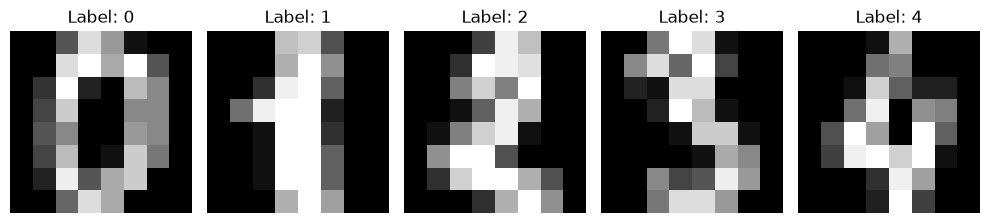

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(10, 3))

for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

**A2(b)**

In [15]:
# Shape of one image
print("Shape of one image:", digits.images[0].shape)

# Shape of original image data
print("Original image data shape:", digits.images.shape)

# Flatten the images
X_flat = digits.images.reshape(digits.images.shape[0], -1)

print("Flattened feature matrix shape:", X_flat.shape)

Shape of one image: (8, 8)
Original image data shape: (1797, 8, 8)
Flattened feature matrix shape: (1797, 64)


**A2(c)** :

Flattening converts each 8×8 image into a 64-element vector. This removes the original 2D spatial arrangement of pixels, so the model no longer directly knows which pixels are next to each other. However, the pixel intensity values themselves are retained.

**Observation (A2):**

The digits dataset contains 1,797 grayscale images of size 8×8. Each image can be represented as a 64-feature vector by flattening it. While flattening makes the data suitable for standard machine-learning algorithms, it loses the spatial relationship between neighboring pixels.

---

# Section B — attempt any 1 of 2 (4 marks each)

*attempt 1 of 2*

## B1. Three classifiers, one dataset  &nbsp;&nbsp;`[4 marks]`

*Dataset: B1 (digits).*

a. Train KNN, an SVM with an RBF kernel and a random forest on the same split.
b. Report accuracy and macro-F1 for each, plus fit time.
c. Recommend one for a device with tight memory and explain in 4–6 lines.


In [16]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()

X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])

Training samples: 1437
Testing samples: 360
Number of features: 64


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# KNN
knn = KNeighborsClassifier(n_neighbors=5)

# SVM with RBF kernel
svm = SVC(kernel="rbf", random_state=42)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the models
knn.fit(X_train, y_train)
svm.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("All three models trained successfully.")

All three models trained successfully.


In [18]:
import time
from sklearn.metrics import accuracy_score, f1_score

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)": SVC(kernel="rbf", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    start_time = time.perf_counter()
    
    model.fit(X_train, y_train)
    
    fit_time = time.perf_counter() - start_time
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    
    results[name] = {
        "Accuracy": accuracy,
        "Macro-F1": macro_f1,
        "Fit Time (s)": fit_time
    }

for name, result in results.items():
    print(f"\n{name}")
    print(f"Accuracy: {result['Accuracy']:.4f}")
    print(f"Macro-F1: {result['Macro-F1']:.4f}")
    print(f"Fit Time: {result['Fit Time (s)']:.6f} seconds")


KNN
Accuracy: 0.9833
Macro-F1: 0.9830
Fit Time: 0.001719 seconds

SVM (RBF)
Accuracy: 0.9917
Macro-F1: 0.9916
Fit Time: 0.021744 seconds

Random Forest
Accuracy: 0.9611
Macro-F1: 0.9607
Fit Time: 0.272981 seconds


**B1(c)** :

For a tight-memory device, KNN would be a suitable choice because its training time is extremely low and it achieved a high accuracy of 98.33%. Although SVM (RBF) gives the highest accuracy of 99.17%, it takes more time to train. Random Forest has the longest training time among the three models and gives the lowest accuracy. Therefore, KNN provides a good balance between performance and efficiency when memory and computational resources are limited.

**Observation (B1):**

For a tight-memory device, KNN would be a suitable choice because its training time is extremely low and it achieved a high accuracy of 98.33%. Although SVM (RBF) gives the highest accuracy of 99.17%, it takes more time to train. Random Forest has the longest training time among the three models and gives the lowest accuracy. Therefore, KNN provides a good balance between performance and efficiency when memory and computational resources are limited.

---

# Section C — compulsory (2 marks)

*compulsory*

## C1. Does more resolution help  &nbsp;&nbsp;`[2 marks]`

*Datasets: B1 and B2.*

a. Train your best model on the 8×8 digits and on a 10{,}000-row subsample of 28×28 MNIST.
b. Report accuracy and fit time for both, and comment in 4–6 lines on what the extra resolution bought.


In [19]:
import time
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load 8x8 Digits dataset
digits = load_digits()

X_digits = digits.data
y_digits = digits.target

# Same 80/20 stratified split
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits,
    y_digits,
    test_size=0.20,
    stratify=y_digits,
    random_state=42
)

# Train SVM
svm_digits = SVC(kernel="rbf", random_state=42)

start_time = time.perf_counter()
svm_digits.fit(X_train_d, y_train_d)
digits_fit_time = time.perf_counter() - start_time

# Test accuracy
y_pred_d = svm_digits.predict(X_test_d)
digits_accuracy = accuracy_score(y_test_d, y_pred_d)

print("8x8 Digits")
print("Accuracy:", digits_accuracy)
print("Fit Time:", digits_fit_time, "seconds")

8x8 Digits
Accuracy: 0.9916666666666667
Fit Time: 0.027358399995137006 seconds


In [20]:
from sklearn.datasets import fetch_openml

# Load MNIST dataset
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X_mnist = mnist.data
y_mnist = mnist.target.astype(int)

print("MNIST data shape:", X_mnist.shape)
print("MNIST target shape:", y_mnist.shape)

MNIST data shape: (70000, 784)
MNIST target shape: (70000,)


In [21]:
# Take a reproducible subsample of 10,000 MNIST rows
X_mnist_10k, _, y_mnist_10k, _ = train_test_split(
    X_mnist,
    y_mnist,
    train_size=10000,
    stratify=y_mnist,
    random_state=42
)

# Split the 10,000 samples into 80% training and 20% testing
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mnist_10k,
    y_mnist_10k,
    test_size=0.20,
    stratify=y_mnist_10k,
    random_state=42
)

print("Subsample shape:", X_mnist_10k.shape)
print("Training samples:", X_train_m.shape[0])
print("Testing samples:", X_test_m.shape[0])
print("Number of features:", X_train_m.shape[1])

Subsample shape: (10000, 784)
Training samples: 8000
Testing samples: 2000
Number of features: 784


In [22]:
# Train SVM (RBF) on 28x28 MNIST
svm_mnist = SVC(kernel="rbf", random_state=42)

start_time = time.perf_counter()

svm_mnist.fit(X_train_m, y_train_m)

mnist_fit_time = time.perf_counter() - start_time

# Test accuracy
y_pred_m = svm_mnist.predict(X_test_m)
mnist_accuracy = accuracy_score(y_test_m, y_pred_m)

print("28x28 MNIST (10,000 samples)")
print("Accuracy:", mnist_accuracy)
print("Fit Time:", mnist_fit_time, "seconds")

28x28 MNIST (10,000 samples)
Accuracy: 0.957
Fit Time: 6.361117899999954 seconds


**Observation (C1):**

The 8×8 Digits dataset achieved an accuracy of 99.17% with a very low fit time of 0.0274 seconds. The 28×28 MNIST dataset achieved 95.70% accuracy, while its fit time increased significantly to 6.3611 seconds. Although the higher resolution provides more pixel features (784 instead of 64), it did not improve accuracy in this experiment. Therefore, the additional resolution increased computational cost without providing a better classification result for this particular SVM setup.